# 머신러닝 실습 - 자전거 데이터 분석  

## I. 서론 
1. 미션 요구사항
- 자전거 대여 패턴을 분석하여 자전거 배치 및 운영 전략을 최적화하고, 대여 수요를 정확히 예측하는 것입니다.   
이를 통해 대여 시스템의 효율성을 높이고 사용자 만족도를 증가시키는 방법을 찾는 것이 이번 미션의 핵심입니다.
- 이번 미션의 최종 목표는 RMSLE (Root Mean Squared Logarithmic Error)를 최대한 낮추는 것입니다. 
다양한 머신러닝 모델과 전략을 실험하여 가장 정확한 수요 예측 모델을 개발하고, 그 결과를 보고서에 담아 보세요!

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [42]:
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [43]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = 'NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## I. EDA

1. 데이터 초기 탐색 및 시각화(히스토그램, 박스플롯, 상관관계 분석)
2. 데이터 전처리
    - 중복값, 결측치, 이상치 처리
    - 범주형으로 나타낼 수 있는 수치형은 범주형으로 변환   
    - 날자형 데이터는 datetime으로 변환 / 시간, 요일, 월, 연도 등 필요한 정보를 추출   
3. 전처리 결과 시각화 및 분석   
4. 인사이트 정리     


### 1. 초기 탐색

#### 목표    
1. 각 컬럼의 타입 / 결측값 / 고유값 수 파악  
2. 히스토그램을 통해서 데이터의 분포(좌편향, 우편향 등) 파악
3. 타입 재분류가 필요한 데이터 확인
4. 히트맵을 통해서 상관관계를 파악

#### 1-1. 중복값 처리
- 1. 발견된 중복값이 없으므로 별도의 처리 X

In [44]:
train_duplicated = train_df.duplicated().sum()
test_duplicated = test_df.duplicated().sum()
print(f"train_df duplicted: {train_duplicated}")
print(f"test_df duplicated: {test_duplicated}")

train_df duplicted: 0
test_df duplicated: 0


#### 1-2. Info, Describe 관찰 결과(타겟 변수는 볼드 처리!)
1. **결측치**: train, test 데이터프레임 둘 모두 없음  
2. **숫자형**: season, holiday, workingday, weather, temp, atemp, humidity, windspeed, **casual, registered, count**  
3. **범주형**: X  
4. **날자형**: datetime   
5. **컬럼 총 개수**: 10886개  

##### 인사이트
1. season, holiday, workingday, weather 등의 변수는 이름도 그렇고, 데이터 통계도 그렇고 범주형으로 전환하는게 적절해 보임   
2. datetime 데이터를 보아, 데이터는 1시간별로 집계된 것임을 알 수 있음. 
3. 날자형 데이터를 year, month, weekday, hour 등의 파생 변수를 만드는데 사용할 것     

In [45]:
train_df.info()
test_df.info()
train_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   str    
 1   season      6493 non-null   int64  
 2   hol

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [46]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
test_df['datetime'] = pd.to_datetime(test_df['datetime'])

train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------    

#### 1-3. 히스토그램 관찰 결과

**1. 수치형이 아닌 범주형으로 보이는 변수 발견**
- season, holiday, workingday, weather

**2. 각 변수별 의미**
- season: 1(봄), 2(여름), 3(가을), 4(겨울)
- holiday: 0(평일), 1(공휴일)
- workingday: 0(주말/휴일), 1(근무일)
- weather: 1(맑음), 2(구름낌/안개), 3(약간의 비/눈), 4(폭우/폭설)

**3. 데이터 분포 분석**
- 3-1. 수치형
    - 우편향: casual, registered, count, windspeed
    - 편향 거의 없음: temp, atemp, humidity
- 3-2. 범주형 
    - weather: 계절 정보는 균등하게 있음  
    - holiday: 평일 데이터가 공휴일 데이터보다 많음  
    - workingday: 근무일 데이터. holiday와 다르게 주말/휴일 둘다 포함이라 주말/휴일 데이터가 좀더 많아 보임    
    - weather: 날자가 1 -> 2 -> 3 -> 4로 감에 따라 데이터가 2배 이상씩 줄고 있음   

##### 인사이트 
1. windspeed가 0인 날이 결측값인지, 실제 무풍인 날이었을지 아니면 결측값인지가 애매함     
2. 히스토그램 분포를 관찰해본 결과, 우편향 데이터를 발견함. 로그 스케일을 취해서 정규분포로 만들어줄 필요성이 있어보임     
3. casual, registered, count 변수가 0인 케이스가 많은데, 예약자가 0인 시간대가 있는 것 자체는     
 특별한 케이스는 아니므로 이상치 처리할 필요성은 없어보임     
4. 추후 모델 학습 시 성능이 만족스럽지 않을 경우, 각 변수를 count로 묶어서 이상치를 관측해볼 예정임   

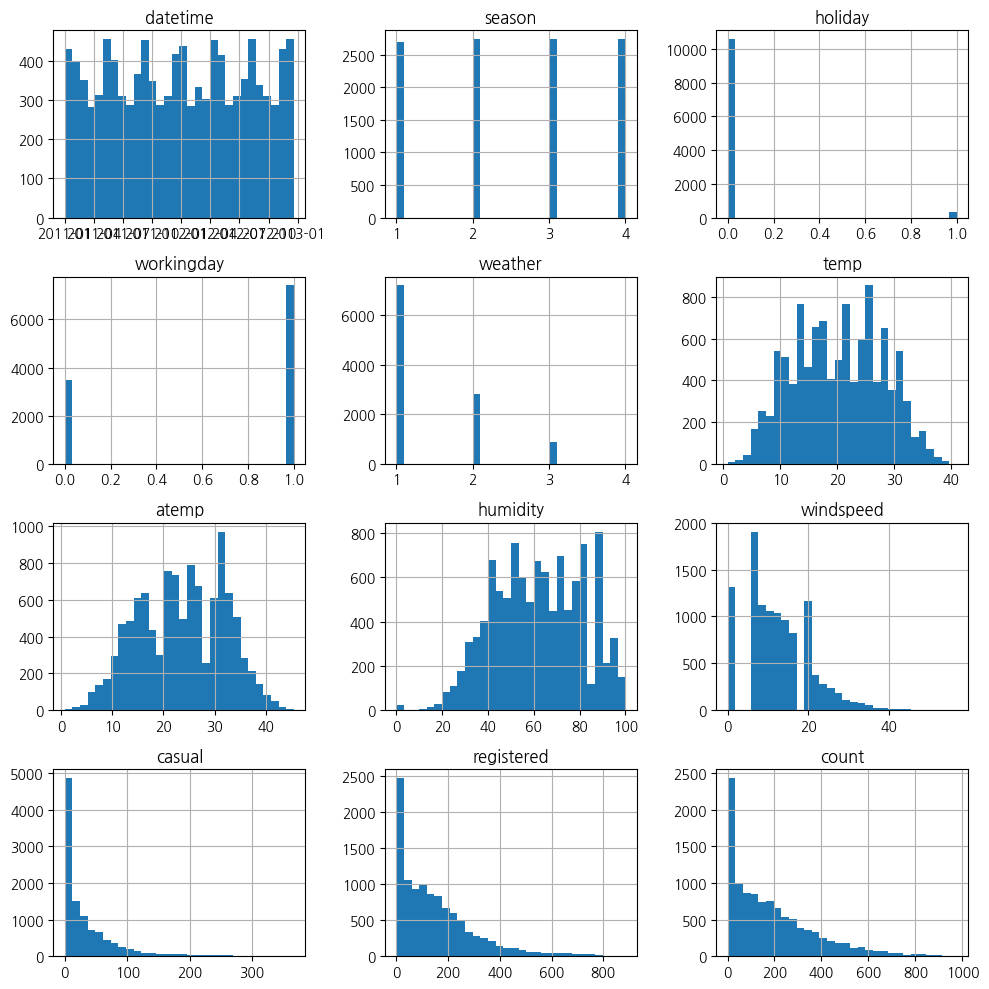

In [47]:
train_df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()
plt.show()

#### 1-4. BoxPlot 관찰 결과
1. 히스토그램 관측 결과 우편향이었던 windpspeed, casual, registered, count 변수에서 IQR을 벗어난 수치 다수 발견 
2. 다른 변수에서는 히스토그램 관측 결과와 동일하게 특별한 이상치가 발견되지는 않아보임 

##### 인사이트  
1. 히스토그램 관찰 결과랑 크게 다른 결론을 도출하진 못헀다. 

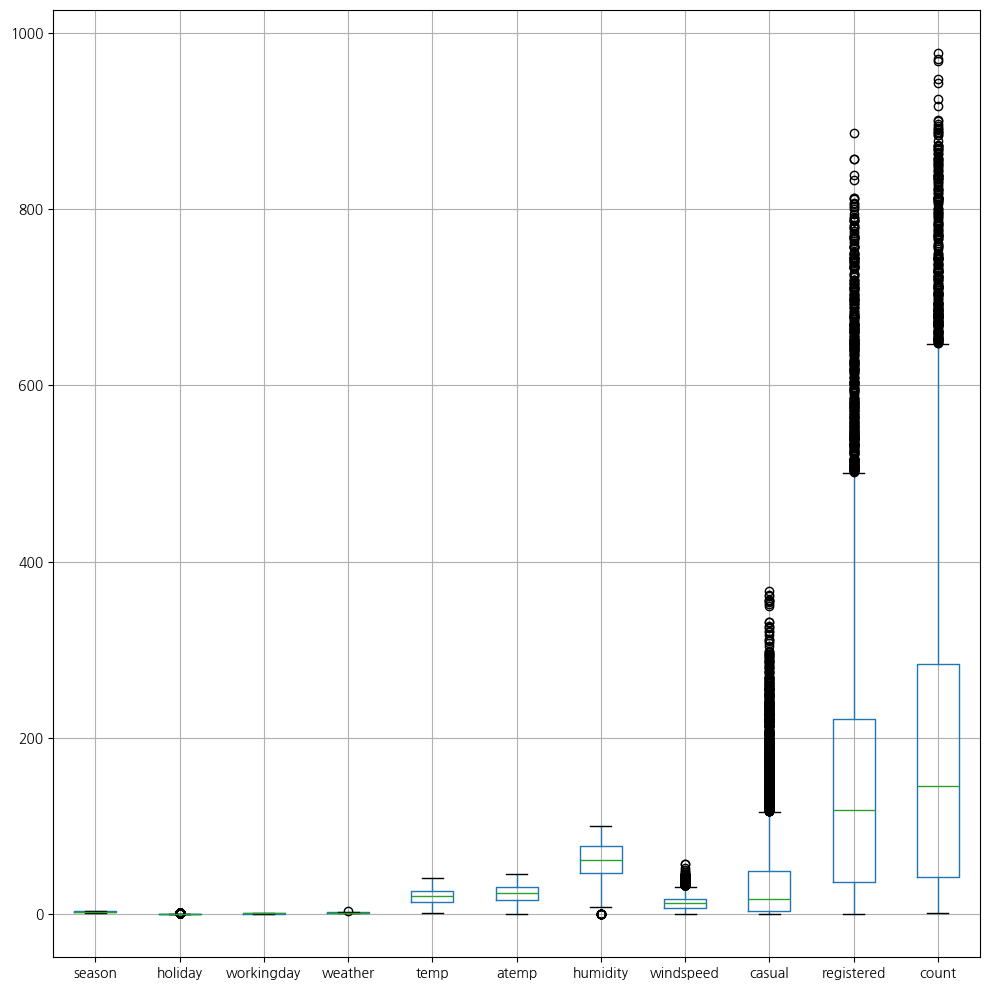

In [48]:
train_df.boxplot(figsize=(10, 10))
plt.tight_layout()
plt.show()

#### 1-5. 상관관계 히트맵 관찰 결과 
1. temp와 atemp는 상관계수가 매우 높으므로, 다중공선성 발생 여부가 매우 높아 보임 
2. temp와는 count는 0.39라는 꽤 강한 양의 상관관계를 띄고 있음. 
3. humidity와 count는 -0.32라는 음의 상관관계를 띄고 있음.
4. temp와 casual은 0.47, registered는 0.32의 상관관계를 갖고 있음. 
5. humidity와 casual은 -0.35, registered는 -0.27의 상관관계를 갖고 있음. 

##### 인사이트 
1. 2, 3번에 의해서, temp와 humidity는 count 값에 직접적인 영향을 미치는 중요한 변수임을 알 수 있다.  
2. 4, 5번에 의해서, 비회원(casual) 고객이 온도 변화나 습도 변화에 더 민감하게 반응한다는 것을 알 수 있다.  

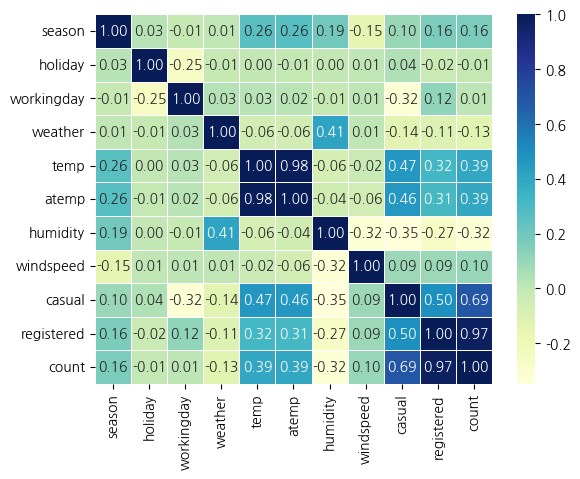

In [49]:
# 먼저 연속형 데이터만 선정
seq = train_df.select_dtypes(include='number') # 수치형 선택
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap='YlGnBu', annot=True, fmt='.2f', linewidths=0.5)
plt.show()

### 2. 데이터 전처리
#### 목표    
- 전처리에 필요한 데이터를 판별해서 전처리용 함수 미리 작성하기   
- 여기서 작성된 함수들은 추후 학습/테스트 데이터셋 분리 이후 전처리 수행할 예정(데이터 누수 방지!)    
- **2-1. 피쳐 엔지니어링**   
    - 날자형 분리 작업: year, month, weekday, hour, is_weekend 
    - datetime 제거 작업    
- **2-2. 결측치 처리**  
    - 결측치가 없으므로 과정 생략
- **2-3. 이상치 처리**  
    - 모델 성능 측정 후, count값으로 묶어서 이상치 측정 예정  
- **2-4. 수치형 스케일링** 
    - 우편향인 windpspeed, casual, registered, count에 적용
    - 나머지 수치형 데이터에는 standard-scaler 적용
- **2-5. 범주형 인코딩**
    - 범주형 데이터인 One-Hot 인코딩으로 전환
- **2-6. 함수 통합**  
    - 2-1~2-5에서 작성된 함수를 하나로 묶음   

#### 2-1. 피쳐 엔지니어링
1. 날짜형 데이터 분리 작업 수행 
2. 필요없어진 datetime은 제거

In [50]:
# 1. 기준이 되는 preprocessor 함수들을 정의
def preprocess_datetime(df):
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['weekday'] = df['datetime'].dt.weekday
    df['hour'] = df['datetime'].dt.hour
    df['is_weekend'] = df['weekday'].apply(lambda x: x >= 5).astype(int)
    
    
    df.drop(columns=['datetime'], inplace=True)
    return df

# 2. 이를 조합하여 최종적으로 사용할 build_features 함수를 정의
def build_features(df):
    return preprocess_datetime(df)

#### 2-2. 결측치 처리
1. 결측치가 없으므로 처리하지 않음

In [51]:
def handle_na(df):
    return df

#### 2-3. 이상치 처리
1. 모델을 테스트하기 이전, 이상치를 제거하거나 대체하지 않을것이므로 처리하지 않음

In [52]:
def handle_outliers(df): 
    return df

#### 2-4. 수치형 스케일링
1. 풍속과 타겟 변수들이 우편향 경향을 보였으므로, 로그 스케일을 취해 줌 
2. 나머지 변수들은 StandardScaler로 변환
3. 연도 변수는 값이 너무 크므로 2010을 빼서 1, 2, 3 꼴로 변환    
4. 타겟 변수는 추후 다시 원상복구시켜야 함!   

In [53]:
from sklearn.preprocessing import StandardScaler

def apply_log_scale(df, cols):
    df[cols] = np.log1p(df[cols])
    return df

def apply_standard_scale(df, cols):
    scaler = StandardScaler()
    df[cols] = scaler.fit_transform(df[cols])
    return df

def apply_year_scaling(df):
    df['year'] = df['year'] - 2010
    return df

def apply_scales(df):
    df = apply_standard_scale(df, ['temp', 'humidity'])
    df = apply_year_scaling(df)
    df = apply_log_scale(df, ['windspeed'])
    return df

def apply_integrated_target_scale(s):
    return np.log1p(s)

def apply_separated_target_scale(df):
    return np.log1p(df)

#### 2-5. 범주형 인코딩
1. 이진형 데이터를 제외한 범주형 데이터를 대상으로 원-핫 인코딩 수행  

In [54]:
def apply_one_hot_encoding(df, cols):
    df = pd.get_dummies(df, columns=cols)
    return df

def apply_encoding(df):
    return apply_one_hot_encoding(df, ['season', 'weather'])

#### 2-6. 전처리 과정 통합 함수 작성
1. 피쳐스 엔지니어링 -> 결측치 처리 -> 이상치 처리 -> 스케일링/인코딩 순으로 진행 
2. 추후 학습/테스트 데이터 분리 후 해당 함수 수행 예정  
3. 원본 데이터프레임에 영향을 미치지 않게 복사본으로 진행  
4. 타겟 변수 전처리는 직접 호출해서 처리할 것  

In [55]:
def preprocess(df): 
    c_df = df.copy()
    build_features(c_df)
    handle_na(c_df)
    handle_outliers(c_df)
    apply_scales(c_df)
    apply_encoding(c_df)
    
    return c_df

### 3. 전처리 후 시각화
#### 목표 
1. 전체 데이터에 전처리를 적용한 뒤, 이를 시각화함으로써 데이터가 제대로 전처리되었는지를 검증
2. 피쳐 엔지니어링을 통해 추가로 얻은 변수와 상관 관계 또한 파악

In [56]:
preprocessed_train_df = preprocess(train_df)
preprocessed_train_df = apply_integrated_target_scale(preprocessed_train_df)
preprocessed_train_df = apply_separated_target_scale(preprocessed_train_df)

preprocessed_train_df.head()

c:\Users\Nighthom\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,weekday,hour,is_weekend
0,0.526589,0.0,0.0,0.526589,NaN,1.317492,0.524579,0.0,0.869742,1.291725,1.343703,0.526589,0.526589,1.026672,0.000000,0.526589
1,0.526589,0.0,0.0,0.526589,NaN,1.303841,0.508823,0.0,1.162283,1.503301,1.550446,0.526589,0.526589,1.026672,0.526589,0.526589
2,0.526589,0.0,0.0,0.526589,NaN,1.303841,0.508823,0.0,1.026672,1.466077,1.503301,0.526589,0.526589,1.026672,0.741276,0.526589
3,0.526589,0.0,0.0,0.526589,NaN,1.317492,0.418476,0.0,0.869742,1.223156,1.291725,0.526589,0.526589,1.026672,0.869742,0.526589
4,0.526589,0.0,0.0,0.526589,NaN,1.317492,0.418476,0.0,0.000000,0.526589,0.526589,0.526589,0.526589,1.026672,0.959135,0.526589


#### 3-1. 히스토그램 관찰 결과
1. 우편향 데이터였던 타겟 변수들(casual, registered, count)가 적당하게 정규분포를 따르게 되었음을 알 수 있다.   
2. windspeeds는 0인 데이터가 너무 많다. 제대로 정규화되었다고 보기 어려움.   

##### 인사이트 
1. 타겟 변수들은 적절히 정규화가 완료되었음을 알 수 있다.  
2. 풍속이 0인 날이 너무 많아, 제대로 정규화가 되지 않았다.    
만약 모델의 성능이 잘 나오지 않는다면, 최우선적으로 탐색해야 하는 변수로 보인다.   

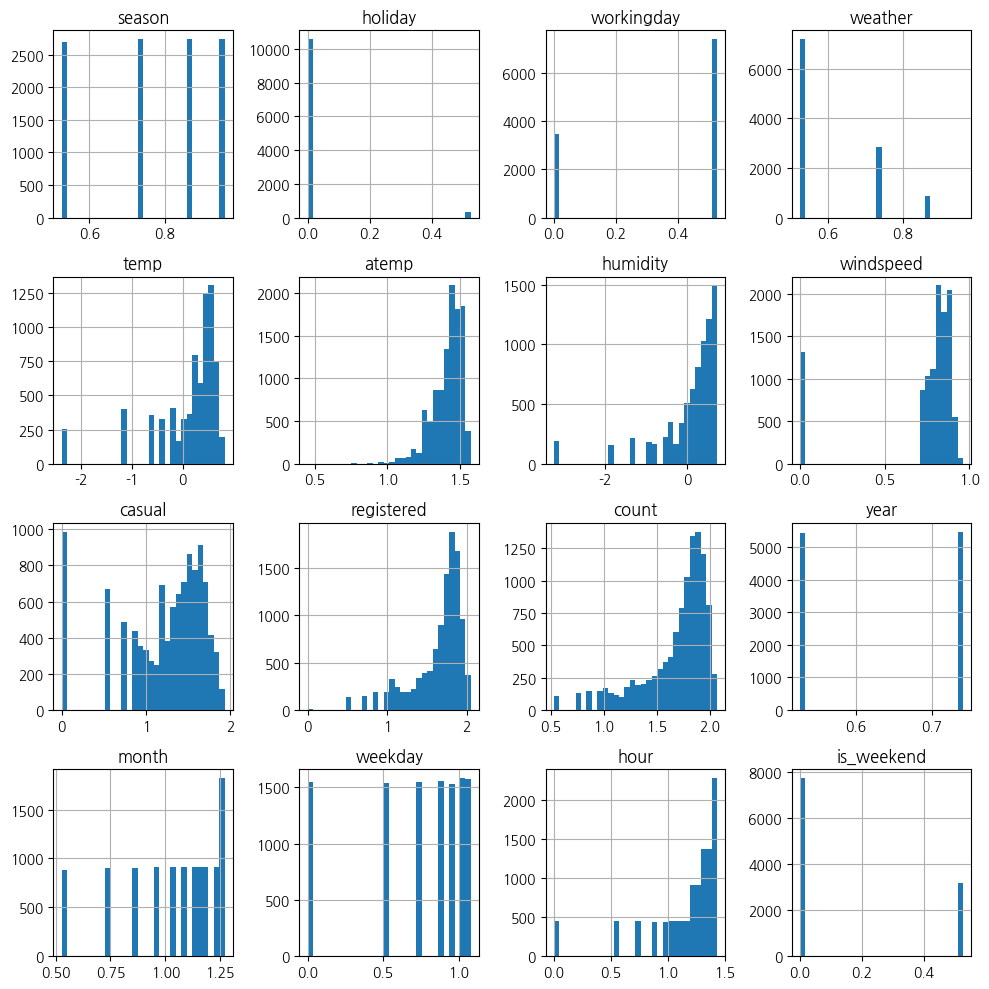

In [57]:
preprocessed_train_df.hist(bins=30, figsize=(10, 10))
plt.tight_layout()
plt.show()

#### 3-2. BoxPlot 관찰 결과  
- 0값이 극단적으로 많은 windspeed를 제외하고는, 특별히 처리해야할 이상치는 보이지 않는다.

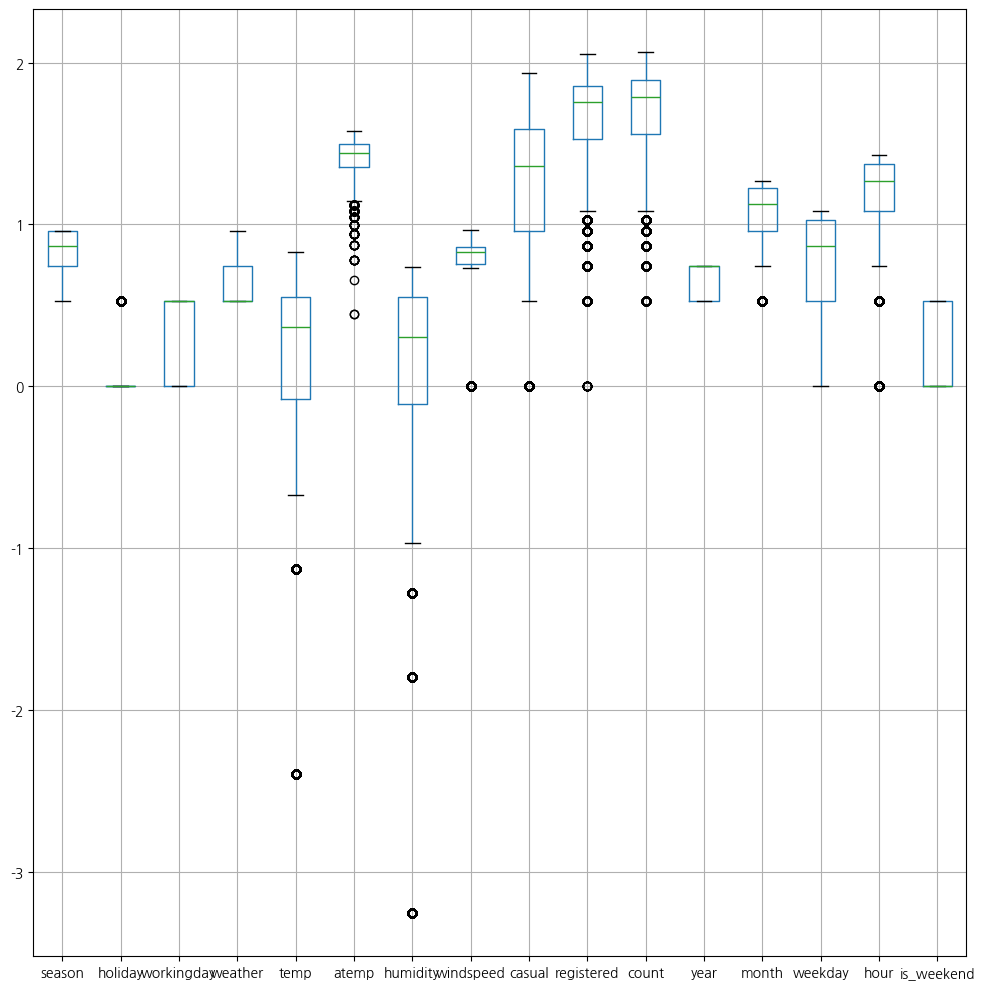

In [58]:
preprocessed_train_df.boxplot(figsize=(10, 10))
plt.tight_layout()
plt.show()

#### 3-3. 상관관계 히트맵 관찰 결과   
1. 새롭게 얻어낸 변수인 weekday와 is_weekend는 높은 상관관계를 보인다(사실 둘다 요일 기반이므로 당연함)  

##### 인사이트   
1. 비록 weekday와 weekend는 높은 상관관계를 보일지라도,   
    - 요일별로 달라지는 자전거 예약 패턴(예, 금요일에 예약율이 높아지는 패턴 등)  
    - 평일/주말 사이의 예약률 변화   
- 두 변수는 이러한 핵심 인사이트를 담고 있어서 제거하기 어렵습니다.   

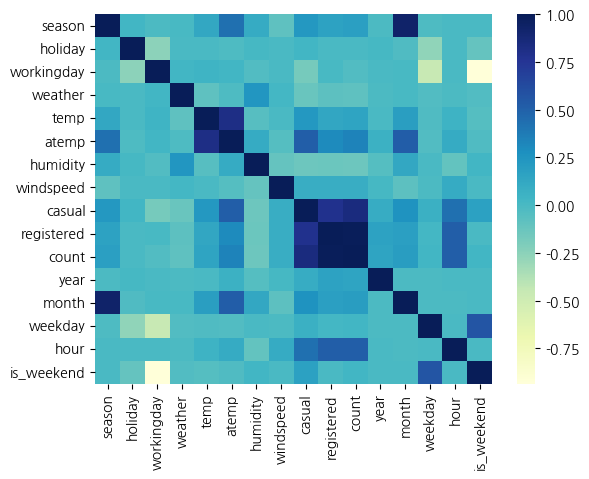

In [59]:
# 먼저 연속형 데이터만 선정
seq = preprocessed_train_df.select_dtypes(include='number') # 수치형 선택
corr = seq.corr(method='pearson')
sns.heatmap(corr, cmap='YlGnBu')
plt.show()

### 4. 인사이트 및 요약 (타겟 변수는 볼드 처리!)
1. 변수 분류
    1. 수치형 변수: temp, atemp, humidity, windspeed, **casual, registered, count**    
    2. 시간형 변수: year, month, hour, weekday, is_weekend
    3. 범주형 변수: season, holiday, workingday, weather
2. 범주형 변수 의미 
    1. season: 1(봄), 2(여름), 3(가을), 4(겨울)
    2. holiday: 0(평일), 1(공휴일)
    3. workingday: 0(주말/휴일), 1(근무일)
    4. weather: 1(맑음), 2(구름낌/안개), 3(약간의 비/눈), 4(폭우/폭설)

3. 다중공선성 발생 염려가 있는 변수  
    - 변수 선정시에 하나만 남기고 제거  
    1. temp, atemp  

4. 편향 데이터 처리결과 
    - 우편향 데이터 windspeed, casual, registered, count에 로그스케일 적용 결과 
    1. windspeed는 0이 너무 많아 제대로 정규분포가 만들어지지 않음(모델 성능이 제대로 안나올 경우 최우선 분석 대상)
    2. 타겟 변수인 casual, registered, count는 적절하게 정규분포를 따르게 변환됨 

5. 모델 성능 안나올 경우 
    1. windspeed의 0 값을 결측값으로 보고 적절하게 처리  
    2. 각 변수를 count로 묶어서 심화 EDA 실행  


## II. 입력 변수, 결과 변수 선정 
### 목표
1. EDA 결과 상으로, 다중공선성 발생이 가능한 변수는 제거   
2. 명백하게 의미가 없어보이는 변수는 미리 제거   

### 선정 결과
#### 1. 입력 변수
- 숫자형: temp, humidity, windspeed  
- 범주형: season, holiday, workingday, weather   
- 날자형: year, month, hour, is_weekend   
- atemp 변수는 다중공선성 발생 가능성이 높으므로 제거  

#### 2. 결과 변수
- **count**: 모델에 직접 count값을 학습시키는 케이스   
- **casual, registered**: 우리의 목표값인 count가 casual+registered이므로, 두 변수를 분리해서 학습시키는 케이스     
- 두 경우를 분리해서 진행하고 양자간의 성능 비교를 통해 최적의 모델 도출   

In [60]:
X = train_df.copy()
X.drop(columns=['atemp', 'casual', 'registered', 'count'], inplace=True)
INTEGRATED_Y = train_df['count']
SEPARATED_Y = train_df[['casual', 'registered']]

## 데이터 세트 구성
### 목표  
- 스케일링/인코딩이 완료된 입력 변수를 하나의 리스트로 통합
- 학습용 데이터와 평가용 데이터 분리  

In [61]:
from sklearn.model_selection import train_test_split

x_train, x_test, iy_train, iy_test, sy_train, sy_test = train_test_split(
    X, INTEGRATED_Y, SEPARATED_Y, test_size=0.2, random_state=42
)

# 결과 저장 구조
results = {
    "통합모델": {"x_train": x_train, "x_test": x_test, "y_train": iy_train, "y_test": iy_test, "pred": None},
    "분리모델": {"x_train": x_train, "x_test": x_test, "y_train": sy_train, "y_test": sy_test, "pred": None},
}

print(results["통합모델"]["x_train"].shape, results["통합모델"]["y_train"].shape)

(8708, 8) (8708,)


## 데이터 전처리 
### 목표
- 데이터 누수를 막기 위해서 학습/테스트 데이터 분리 후 데이터 전처리 진행!  
- 전처리 파이프라인은 이미 EDA-데이터 전처리 파트에 작성해 두었음!

In [62]:
# X값 대상으로 전처리
x_train = preprocess(x_train)
x_test = preprocess(x_test)

# y값 대상으로 전처리 
iy_train = apply_integrated_target_scale(iy_train)
sy_train = apply_separated_target_scale(sy_train)
iy_test = apply_integrated_target_scale(iy_test)
sy_test = apply_separated_target_scale(sy_test)

## 모델 세팅 
- 학습에 사용할 모델들을 미리 세팅해둠  
- 또한, 학습에 사용할 함수들도 미리 작성해 둠으로써 편하게 작업할 예정

In [63]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_squared_log_error, r2_score
import numpy as np

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "BayesianRidge": BayesianRidge(),
    "SGD": SGDRegressor(max_iter=1000, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
}
    
def run_integrated_models(models, x_train, y_train, x_test, y_test):
    results_table = []

    for name, model in models.items():
        # 모델 학습 (log1p 상태)
        model.fit(x_train, y_train)
        log_pred = model.predict(x_test)

        #  로그 → 원래 스케일 복구
        pred = np.expm1(log_pred)
        true = np.expm1(y_test)

        # RMSLE 
        rmsle = np.sqrt(mean_squared_log_error(true, pred))

        # R2 Score
        r2 = r2_score(y_test, log_pred)

        results_table.append({
            "모델": name,
            "RMSLE": rmsle,
            "R2": r2
        })

    return pd.DataFrame(results_table).sort_values("RMSLE")

def run_separated_models(models, x_train, y_train, x_test, y_test):
    results_table = []

    for name, model in models.items():
        # casual 학습
        model.fit(x_train, y_train['casual'])
        casual_pred = model.predict(x_test)
        
        # registered 학습
        model.fit(x_train, y_train['registered'])
        registered_pred = model.predict(x_test)
        
        # 로그 상태에서 합산
        log_pred = casual_pred + registered_pred
        log_true = y_test['casual'] + y_test['registered']
        
        # RMSLE (로그 스케일에서 MSE 기반 계산)
        rmsle = np.sqrt(mean_squared_error(log_true, log_pred))
        
        # R2 (로그 스케일 기준)
        r2 = r2_score(log_true, log_pred)
        
        results_table.append({
            "모델": name,
            "RMSLE": rmsle,
            "R2": r2
        })

    return pd.DataFrame(results_table).sort_values("RMSLE").set_index("모델")

## 모델 학습 및 평가  
- 선정된 모델: 선형 회귀, 릿지, 라쏘, 베이시안 릿지, SGD 회귀, KNN 회귀
- 선정된 평가 지표: RMSLE, RMSE, R2

In [64]:
integrated_models = run_integrated_models(models, x_train, iy_train, x_test, iy_test)
seperated_models = run_separated_models(models, x_train, sy_train, x_test, sy_test)

In [65]:
integrated_models.info()

<class 'pandas.DataFrame'>
Index: 6 entries, 5 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   모델      6 non-null      str    
 1   RMSLE   6 non-null      float64
 2   R2      6 non-null      float64
dtypes: float64(2), str(1)
memory usage: 192.0 bytes


In [66]:
seperated_models

,RMSLE,R2
모델,,
KNN,0.762302,0.923895
LinearRegression,1.825306,0.563652
Ridge,1.825308,0.563651
BayesianRidge,1.825314,0.563648
SGD,1.834698,0.559150
Lasso,2.312534,0.299614
